---
tags: [algorithm, primitive, resource-estimation]
---

# 量子位相推定（QPE）入門

量子位相推定（Quantum Phase Estimation; QPE）は、$U|\psi\rangle = e^{2\pi i \phi}|\psi\rangle$を満たすユニタリ$U$と固有状態$|\psi\rangle$から、固有位相$\phi$を推定するアルゴリズムです。Shorのアルゴリズムなど、ユニタリの固有値に埋め込まれた位相を使うアルゴリズムで中心的なプリミティブとして使われます{cite:p}`10.48550/arXiv.quant-ph/9511026,10.1098/rspa.1998.0164`。

このノートブックでは、組み込みの`qpe`ヘルパーを4x4ユニタリに適用します。既知の固有状態を準備し、ローカルのQiskitシミュレータで回路を実行して、復号された位相を既知の固有位相と比較します。さらに、カウント用量子ビットを増やすと精度が上がることを確認し、リソース推定を使って、必要な精度に対する計算量の増え方を見ます。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
# 数値計算、プロット、シミュレータ、Qamomileのユーティリティを読み込みます。
import math
import os

import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

# QPEの回路構造が見えるように、複合ゲートを分解して扱います。
transpiler = QiskitTranspiler(use_native_composite=False)

## 背景: 位相キックバックと量子フーリエ変換

QPEは、制御ユニタリーゲートによる位相キックバック{cite:p}`10.1098/rspa.1998.0164`と、量子フーリエ変換{cite:p}`10.48550/arXiv.quant-ph/0201067`を組み合わせます。

### 位相キックバック

位相キックバックは、対象レジスタの固有位相を制御レジスタへ移します。次を仮定します。

$$
U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle.
$$

1つの制御量子ビットを重ね合わせにし、対象レジスタを$|\psi\rangle$のままにします。

$$
\frac{|0\rangle + |1\rangle}{\sqrt{2}}|\psi\rangle.
$$

$U$に対応する制御ユニタリーゲートは、制御量子ビットが$|1\rangle$の枝にだけ$U$を適用します。対象レジスタは固有状態なので、その枝に固有位相が乗ります。

$$
\frac{|0\rangle|\psi\rangle + |1\rangle U|\psi\rangle}{\sqrt{2}}
=
\frac{|0\rangle + e^{2\pi i\phi}|1\rangle}{\sqrt{2}}|\psi\rangle.
$$

対象レジスタは同じ固有状態に戻り、制御量子ビットが位相を持ちます。QPEはこの仕組みを制御ユニタリーゲートで繰り返します。制御ユニタリーゲート（$U^{2^k}$）は位相$e^{2\pi i 2^k\phi}$をキックバックするため、異なる制御量子ビットが同じ固有位相の異なる2進重みを受け取ります。QPEでは、それぞれの制御量子ビットを個別に測定せず、キックバックされた位相を測定前まで保ちます。

### 量子フーリエ変換

$M=2^m$個の基底状態に対するQFTは

$$
\mathrm{QFT}_M|x\rangle
= \frac{1}{\sqrt{M}}
  \sum_{y=0}^{M-1} e^{2\pi i xy/M}|y\rangle.
$$

これは整数$x$を、計算基底全体にわたる規則的な位相パターンへ写します。詳しい説明はQFTチュートリアルをご覧ください。逆QFTはその逆の操作です。$\phi=a/M$が$m$ビットで正確に表せる場合、制御ユニタリーゲート（$U^{2^0}, U^{2^1}, \ldots, U^{2^{m-1}}$）によってカウント用レジスタは

$$
\frac{1}{\sqrt{M}}\sum_{k=0}^{M-1} e^{2\pi i a k/M}|k\rangle
= \mathrm{QFT}_M|a\rangle.
$$

ここに$\mathrm{QFT}_M^{-1}$を適用すると$|a\rangle$が返ります。重要なことは、逆QFTによって位相の情報を計算基底のビット列に変換できることです。

$$
\underbrace{
\frac{1}{\sqrt{M}}
\begin{pmatrix}
1 \\
e^{2\pi i a/M} \\
\vdots \\
e^{2\pi i a(M-1)/M}
\end{pmatrix}
}_{\text{位相の値のベクトル}}
\xrightarrow{\mathrm{QFT}_M^{-1}}
\underbrace{|a\rangle = |a_{m-1}\cdots a_0\rangle}_{\text{計算基底のビット列}}.
$$

## アルゴリズム

QPEは、1つの制御量子ビットで見た位相キックバックを、レジスタ全体の手順へ拡張します。カウント用レジスタはまず、すべての2進重みを重ね合わせとして保持します。そこへ$U$の制御ユニタリーゲートを適用すると、対応する重み付きの固有位相がカウント用レジスタへキックバックされます。最後に逆QFTを使い、このフーリエ符号化された位相パターンを通常の2進整数として読み出すことで、$\phi$の推定値を得ます。

対象レジスタへの入力は、$U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle$を満たす$U$のある固有状態$|\psi\rangle$であるとします。$m$ビットの精度で推定したいとし、カウント用レジスタは$|0\rangle^{\otimes m}$から始めます。ここで$M=2^m$とおきます。

:::{note} 固有状態の重ね合わせ
より一般には、対象レジスタへの入力は1つの固有状態に限られません。固有状態の重ね合わせを入力した場合、QPEは入力状態に含まれる各固有状態の重みに応じた確率で、対応する固有位相を測定します。このチュートリアルでは、位相キックバックの式とサンプリング結果を読みやすくするため、既知の固有状態を使います。
:::

### ステップ1：カウント用レジスタを重ね合わせにする

カウント用レジスタにアダマールゲートを適用します。これにより、$M$個のカウント用レジスタの値の一様重ね合わせが作られます。

$$
|\Psi_1\rangle =
H^{\otimes m}|0\rangle^{\otimes m}|\psi\rangle
=
\frac{1}{\sqrt{M}}\sum_{r=0}^{M-1}|r\rangle|\psi\rangle.
$$

### ステップ2：制御ユニタリーゲートを適用する

各カウント用量子ビット$k$に対して、制御ユニタリーゲート（$U^{2^k}$）を適用します。$r=\sum_{k=0}^{m-1} r_k2^k$と書くと、対象の固有状態には位相$e^{2\pi i\phi r}$が乗ります。

$$
|\Psi_2\rangle =
\frac{1}{\sqrt{M}}\sum_{r=0}^{M-1}
e^{2\pi i \phi r}|r\rangle|\psi\rangle.
$$

### ステップ3：逆QFTで復号する

$\phi=a/M$が正確に表せる場合、カウント用レジスタは$\mathrm{QFT}_M|a\rangle$になります。逆QFTを適用すると$|a\rangle$が返ります。

$$
|\Psi_2\rangle =
\left(
  \frac{1}{\sqrt{M}}\sum_{r=0}^{M-1} e^{2\pi i ar/M}|r\rangle
\right)|\psi\rangle
=
\mathrm{QFT}_M|a\rangle|\psi\rangle,
$$

$$
|\Psi_3\rangle =
\mathrm{QFT}_M^{-1}\mathrm{QFT}_M|a\rangle|\psi\rangle
=
|a\rangle|\psi\rangle.
$$

### ステップ4：位相を測定する

カウント用レジスタを測定します。正確に表せる場合、測定結果は$a$となり、位相の推定値は次のようになります。

$$
\tilde{\phi} = \frac{a}{M}.
$$

$\phi$が$m$ビットで正確に表せない場合、分布は最も近い$m$ビット近似の周辺に集中します。$m$を増やすと位相の格子間隔$1/2^m$が小さくなるため、表現可能な位相を真の固有位相へ近づけられます。

:::{note} **2進小数と精度**
2進小数では、小数部に使えるビット数が位相推定値の精度を左右します。たとえば$\phi=0.6$は2進小数では正確に表せません。2ビットで表すと、最も近い2進小数は

$$
0.10_2 = \frac{1}{2^1} + \frac{0}{2^2} = 0.5
$$

です。一方、3ビットまで使うと格子が細かくなり、

$$
0.101_2
= \frac{1}{2^1} + \frac{0}{2^2} + \frac{1}{2^3}
= 0.625
$$

となって、$0.6$により近い表現が得られます。そのため、カウント用量子ビット数を増やすことは、位相推定値として読み出せる2進小数のビット数を増やすことに対応します。
:::

```{figure} assets/qpe_circuit.png
:alt: カウント用レジスタ、制御ユニタリーゲート、逆QFT、測定からなる量子位相推定回路。
:width: 720px

QPE回路の模式図です。カウント用レジスタが制御ユニタリーゲートを通じて位相を蓄積し、逆QFTが蓄積された位相パターンを測定ビット列に変換します。
```

## Qamomileでの実装：`qpe`関数

`qmc.qpe`関数は、QPEのパターン全体を適用します。アダマールゲート、渡したユニタリ量子カーネルに対応する制御ユニタリーゲート、逆QFT、固定小数点の位相復号をまとめて扱えます。

### 問題例

ここでは**対角**4x4ユニタリを使います。

$$
U =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & e^{i\theta_{01}} & 0 & 0 \\
0 & 0 & e^{i\theta_{10}} & 0 \\
0 & 0 & 0 & e^{i\theta_{11}}
\end{pmatrix}.
$$

この行列では、すべての計算基底状態が固有状態です。対象状態$|01\rangle$を準備し、推定したい位相$\theta_{01} / 2\pi$を$0.6$に設定します。$0.6$は2進格子上で正確には表現できないため、カウント用量子ビットを増やす効果が見えやすくなります。

In [3]:
# カウント用レジスタのサイズ、サンプリング設定、対象固有状態を決めます。
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
COUNTING_BIT_OPTIONS = tuple(range(3, 6)) if docs_test_mode else tuple(range(3, 10))
DRAW_COUNTING_BITS = 3
EXAMPLE_COUNTING_BITS = 3
SHOTS = 512 if docs_test_mode else 4096
SAMPLER_SEED = 321
TARGET_BASIS = 1  # |01>

# 対角ユニタリの位相と対象位相を設定します。
TARGET_PHASE_FRACTION = 0.6
phase_fractions = np.array([0.0, TARGET_PHASE_FRACTION, 0.23, 0.81])
phase_fractions[TARGET_BASIS] = TARGET_PHASE_FRACTION
phase_angles = 2 * math.pi * phase_fractions

# 位相をユニタリ行列に変換し、ユニタリ性を確認します。
unitary = np.diag(np.exp(1j * phase_angles))
assert np.allclose(unitary.conj().T @ unitary, np.eye(4))

# 量子カーネルに渡す具体的な位相パラメータを保存します。
PHI_01 = float(phase_angles[1])
PHI_10 = float(phase_angles[2])
PHI_11 = float(phase_angles[3])

# 後続セルで使う問題設定を表示します。
print("phase fractions:", np.round(phase_fractions, 6))
print("target phase fraction:", f"{TARGET_PHASE_FRACTION:.8f}")
print("U =")
print(np.round(unitary, 3))
assert 0.0 <= TARGET_PHASE_FRACTION < 1.0

phase fractions: [0.   0.6  0.23 0.81]
target phase fraction: 0.60000000
U =
[[ 1.   +0.j     0.   +0.j     0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j    -0.809-0.588j  0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     0.125+0.992j  0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     0.   +0.j     0.368-0.93j ]]


### `qpe`による量子カーネルの実装

まず、位相を推定したい4x4ユニタリを定義します。下の`diagonal_4x4`量子カーネルは、この行列を直接実装します。Qamomileでは、`qmc.p(q, theta)`は`q`の$|1\rangle$成分に$e^{i\theta}$を掛けます。そのため、`qmc.p(q[0], phi10)`は対象レジスタの最初のビットが1であるすべての基底状態に位相$e^{i\theta_{10}}$を与え、`qmc.p(q[1], phi01)`は対象レジスタの2つ目のビットが1であるすべての基底状態に位相$e^{i\theta_{01}}$を与えます。この時点で$|11\rangle$には$e^{i(\theta_{10}+\theta_{01})}$が乗っているため、制御位相シフトゲートでは補正分

$$
\theta_{11} - \theta_{10} - \theta_{01}
$$

だけを$|11\rangle$に追加します。これにより、順序付き基底$|00\rangle, |01\rangle, |10\rangle, |11\rangle$に対する対角成分は、ちょうど$\operatorname{diag}(1, e^{i\theta_{01}}, e^{i\theta_{10}}, e^{i\theta_{11}})$になります。

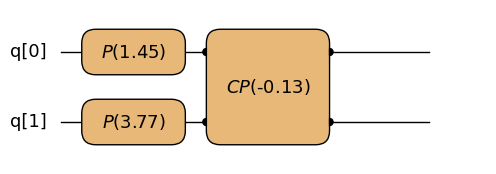

In [4]:
# 位相ゲートで対角4x4ユニタリを実装します。
@qmc.qkernel
def diagonal_4x4(
    q: qmc.Vector[qmc.Qubit],
    phi01: qmc.Float,
    phi10: qmc.Float,
    phi11: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    # 対象ビットごとに位相を付与します。
    q[0] = qmc.p(q[0], phi10)
    q[1] = qmc.p(q[1], phi01)
    # |11>成分が行列の対角要素と一致するよう補正します。
    q[0], q[1] = qmc.cp(q[0], q[1], phi11 - phi10 - phi01)
    return q


# 具体的な位相パラメータを使って対象ユニタリを描画します。
diagonal_4x4.draw(
    q=2,
    phi01=PHI_01,
    phi10=PHI_10,
    phi11=PHI_11,
    fold_loops=False,
)

`qmc.qpe`関数は`QFixed`の位相レジスタを返します。`QFixed`は、量子レジスタで固定小数点数を表すQamomileの型です。ここでは位相を$[0,1)$の小数として保持し、測定すると浮動小数点の位相推定値を直接取得できます。下の量子カーネルでは、固有状態$|01\rangle$を準備し、`diagonal_4x4`にQPEを適用して、復号済みの位相を測定します。ここでは小さなファクトリを使い、同じ問題ユニタリに対してカウント用量子ビット数を変えられるようにします。

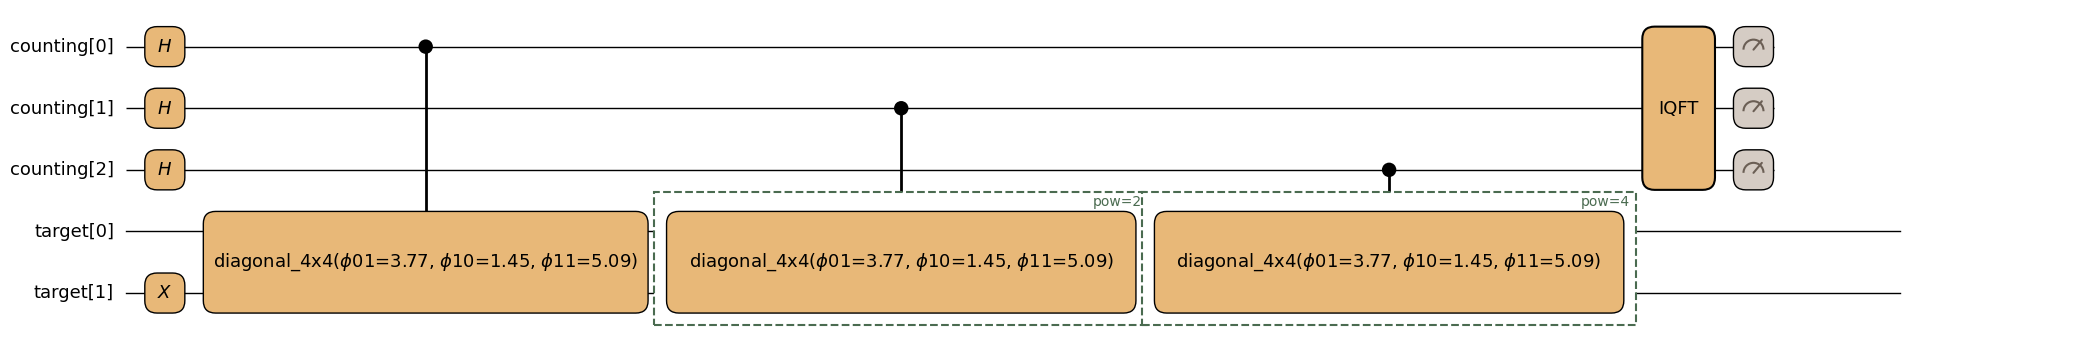

In [5]:
# カウント用レジスタサイズを変えられるQPE量子カーネルを作ります。
def make_qpe_kernel(counting_bits: int):
    @qmc.qkernel
    def qpe_with_stdlib(
        phi01: qmc.Float,
        phi10: qmc.Float,
        phi11: qmc.Float,
    ) -> qmc.Float:
        # カウント用レジスタと2量子ビットの対象レジスタを確保します。
        counting = qmc.qubit_array(counting_bits, name="counting")
        target = qmc.qubit_array(2, name="target")
        # 対象固有状態として|01>を準備します。
        target[1] = qmc.x(target[1])

        # 標準ライブラリのQPEを適用し、復号された固定小数点位相を測定します。
        phase = qmc.qpe(
            target,
            counting,
            diagonal_4x4,
            phi01=phi01,
            phi10=phi10,
            phi11=phi11,
        )
        return qmc.measure(phase)

    return qpe_with_stdlib


# 回路図で使う小さなQPEインスタンスを描画します。
qpe_to_draw = make_qpe_kernel(DRAW_COUNTING_BITS)
qpe_to_draw.draw(
    phi01=PHI_01,
    phi10=PHI_10,
    phi11=PHI_11,
    fold_loops=False,
)

## 実行結果

### 回路のトランスパイルと実行

測定された`QFixed`値は浮動小数点の位相推定値として返るため、ビット列を手動で復号する必要はありません。最初の実行では、回路図と同じ3個のカウント用量子ビットを使います。実験では、`sample_result.results`のうち測定回数が最も多い要素をそのまま表示し、後続セルで使う推定位相だけを返します。

In [6]:
# 対角ユニタリの位相をトランスパイル時に固定します。
bindings = {"phi01": PHI_01, "phi10": PHI_10, "phi11": PHI_11}


# 2つの位相小数の循環距離を計算します。
def phase_distance(a: float, b: float) -> float:
    raw_distance = abs(a - b)
    return min(raw_distance, 1.0 - raw_distance)


# 指定したカウント用レジスタサイズでQPE回路をトランスパイルし、サンプリングします。
def run_qpe_experiment(counting_bits: int) -> float:
    # 位相を固定したQPE量子カーネルを作り、トランスパイルします。
    qpe_kernel = make_qpe_kernel(counting_bits)
    executable = transpiler.transpile(qpe_kernel, bindings=bindings)
    # ドキュメント出力が再現可能になるようシミュレータのseedを固定します。
    executor = transpiler.executor(
        backend=AerSimulator(
            seed_simulator=SAMPLER_SEED + counting_bits,
            max_parallel_threads=1,
        )
    )
    # 測定されたQFixedの位相推定値をサンプリングします。
    sample_result = executable.sample(
        executor,
        shots=SHOTS,
        bindings={},
    ).result()

    # 最も多く観測された復号済み位相を取り出します。
    most_observed_result = max(sample_result.results, key=lambda item: item[1])
    print(most_observed_result)
    qpe_output, most_observed_shots = most_observed_result

    assert 0 < most_observed_shots <= SHOTS
    return qpe_output


# 3個のカウント用量子ビットの例を実行し、期待される格子精度を確認します。
example_phase = run_qpe_experiment(EXAMPLE_COUNTING_BITS)
assert phase_distance(example_phase, TARGET_PHASE_FRACTION) <= (
    1 / 2**EXAMPLE_COUNTING_BITS
)

(0.625, 446)


### カウントレジスタの数と精度

目標位相$0.6$は少ないビット数では正確に表現できないため、QPEは近くの格子点にまたがる分布を返します。ここではカウント用量子ビット数を3から9まで変化させ、`qpe`の最終出力と厳密な位相値を比較します。標準出力には、各カウント用レジスタサイズで測定回数が最も多い`sample_result.results`の要素を表示します。

In [7]:
# すべてのカウント用レジスタサイズでQPEを実行します。
bits = list(COUNTING_BIT_OPTIONS)
estimated_phases = [run_qpe_experiment(counting_bits) for counting_bits in bits]
# 推定値を厳密な位相と比較し、循環距離で誤差を計算します。
exact_phases = [TARGET_PHASE_FRACTION for _ in bits]
phase_errors = [
    phase_distance(estimated_phase, TARGET_PHASE_FRACTION)
    for estimated_phase in estimated_phases
]

# 位相推定値を厳密な位相と並べてプロットします。
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(bits, estimated_phases, marker="o", color="#2696EB", label="QPE estimate")
ax.plot(bits, exact_phases, linestyle="--", color="#DB4D3F", label="exact phase")
ax.set_xlabel("counting qubits")
ax.set_ylabel("phase fraction")
ax.set_xticks(bits)
phase_margin = max(0.02, max(phase_errors) + 0.01)
ax.set_ylim(
    max(0.0, TARGET_PHASE_FRACTION - phase_margin),
    min(1.0, TARGET_PHASE_FRACTION + phase_margin),
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# この例でカウント用量子ビットを増やすと推定が改善することを確認します。
assert phase_errors[-1] < phase_errors[0]
for counting_bits, phase_error in zip(bits, phase_errors):
    assert phase_error <= 1 / 2**counting_bits

(0.625, 446)


(0.625, 302)
(0.59375, 444)


/var/folders/yb/p1l2r62d0bnfz8jt5dz8wj_80000gn/T/ipykernel_1867/3256144127.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## リソース推定

前のサブセクションでは、カウント用量子ビットを増やすと精度が上がることを確認しました。ここでは、上の`run_qpe_experiment()`で使ったものと同じQPE量子カーネルに、`estimate_resources()`を直接適用します。この推定には、アダマールゲート、`qmc.qpe`による制御ユニタリー、逆QFT、最後の固定小数点測定が含まれます。

In [8]:
# 具体的なカウント用量子ビット数を代入し、総ゲート数を集めます。
resource_gate_counts: list[int] = []
for counting_bits in bits:
    qpe_kernel = make_qpe_kernel(counting_bits)
    concrete_estimate = qpe_kernel.estimate_resources(inputs=bindings).simplify()
    resource_gate_counts.append(int(concrete_estimate.gates.total))

# 最初の推定点に合わせて2^mの参照曲線を作ります。
scaling_reference = [
    resource_gate_counts[0] * 2 ** (counting_bits - bits[0])
    for counting_bits in bits
]

# リソース推定とmに対する指数的な傾向をプロットします。
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(
    bits,
    resource_gate_counts,
    marker="o",
    color="#2696EB",
    label="QPE gate count",
)
ax.plot(
    bits,
    scaling_reference,
    linestyle="--",
    color="#DB4D3F",
    label=r"theory: QPE O$(2^m)$",
)
ax.set_xlabel("counting qubits")
ax.set_ylabel("total gates")
ax.set_yscale("log")
ax.set_xticks(bits)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 直接推定したゲート数が、この範囲で増加することを確認します。
assert all(
    later > earlier
    for earlier, later in zip(resource_gate_counts, resource_gate_counts[1:])
)

/var/folders/yb/p1l2r62d0bnfz8jt5dz8wj_80000gn/T/ipykernel_1867/2234288797.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


プロットは、位相の格子を細かくするためのコストを、$2^m$に比例する参照線とともに示しています。目標とする加法誤差を$\epsilon$とすると、格子幅はおおよそ

$$
2^{-m} \lesssim \epsilon
$$

を満たす必要があります。そのため、必要なカウント用量子ビット数は

$$
m = O\!\left(\log\frac{1}{\epsilon}\right)
$$

です。

制御ユニタリーを繰り返しモデルで考える場合、QPEは重み$1,2,\ldots,2^{m-1}$に対応する制御ユニタリーゲートを適用します。したがって、制御ユニタリーゲートの適用回数は

$$
\sum_{k=0}^{m-1} 2^k = 2^m - 1
=
O\!\left(\frac{1}{\epsilon}\right)
$$

です。つまり、カウント用量子ビット数は$1/\epsilon$に対して対数的ですが、繰り返しによる制御ユニタリーゲートの回数は$O(1/\epsilon)$で増えます{cite:p}`10.1017/CBO9780511976667`。

最後に、このスケーリングは実装方法に依存します。QPEでは
$\mathrm{controlled}\text{-}U^{2^0}, \ldots,
\mathrm{controlled}\text{-}U^{2^{m-1}}$という制御ユニタリーが必要です。
これらを$U$の繰り返しで実装する場合、コストは$O(2^m)=O(1/\epsilon)$となり、
高精度では通常効率的ではありません。より一般には、コストは

$$
G_{\mathrm{QPE}}(m)
=
\sum_{k=0}^{m-1} G\!\left(\mathrm{controlled}\text{-}U^{2^k}\right)
+ O(m^2)
$$

と書けます。ここで$G(V)$は、操作$V$を実装するための論理ゲートコストを表します。
このページでは、コストの単位がゲート数であることを明示するために$G$を使います。

:::{note}
$m$個の量子ビットに対する逆QFTは、$O(m^2)$個のゲートに分解できます。詳しくはQFTのチュートリアルを参照してください。
:::

しかし、実際には以下の要因によってこの見積もりは大きく変わる可能性があります。

1. **制御ユニタリーの実装コスト**

   多くの場合、主なコストは各制御ユニタリーをどう実装するかで決まります。
   Shorのアルゴリズムでは、モジュラー乗算に対応する制御ユニタリーを問題構造から構成できるため、
   $U$を指数回反復する必要はありません。量子系のハミルトニアンシミュレーションでも、
   ハミルトニアンの形やシミュレーション手法によっては、制御された時間発展を多項式程度のリソースで実装できる場合があります。
   そのため、QPEのリソースを見積もるときは、制御ユニタリーを$U$の反復として数えるのか、
   直接合成した回路として数えるのか、あるいは問題固有の算術回路やシミュレーション回路として与えるのかを明示する必要があります。

2. **初期状態の準備コスト**

   上の見積もりには、対象レジスタの初期状態を準備するコストも含まれていません。
   QPEを有効に使うには、入力状態が$U$の固有状態であるか、少なくとも固有状態に十分近い状態である必要があります。
   そのような固有状態または近似固有状態を準備する量子回路は非自明なコストを持つ場合があり、
   実際の応用で全体のリソースを評価するときは、この準備コストを別途数える必要があります。


## まとめ

このノートブックでは、対角4x4ユニタリでQPEを実装し、復号された位相をサンプリングして、カウント用レジスタを大きくしたときの精度とリソースの変化を確認しました。

- `qmc.qpe`は、渡したユニタリ量子カーネルに対して、アダマールゲート、制御ユニタリーゲート、逆QFT、固定小数点の位相復号を適用します。
- この例では固有状態$|01\rangle$を準備し、目標位相$0.6$を浮動小数点の`QFixed`測定結果として直接推定します。
- カウント用量子ビットを増やすと2進位相の格子が細かくなるため、サンプリングされた推定値が目標位相に近づきます。
- `estimate_resources()`を直接呼び出すことで、単純な繰り返し実装では$m=O(\log(1/\epsilon))$個のカウント用量子ビットに対して、$O(1/\epsilon)$回の制御ユニタリーゲートが必要になることを確認できます。
- 実際の応用では、制御ユニタリーの実装方法と初期状態の準備コストを含めるかどうかを明示することが重要です。